# import

In [125]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim


# 多値分類

## データ読み込み

In [126]:
iris = load_iris() # データ読み込み

x_org, y_org = iris.data, iris.target

print(x_org.shape)
print(y_org.shape)


(150, 4)
(150,)


## データ絞り込み
クラスは3つ・特徴量は2つ

In [127]:
x_select = x_org[:, [0, 2]] # 2つの特徴量を選択

print(x_select.shape, y_org.shape)


(150, 2) (150,)


## 訓練データと検証データの分離

In [128]:
x_train, x_valid, y_train, y_valid = train_test_split(x_select, y_org, train_size=0.5, test_size=0.5, random_state=123)
print(x_train.shape, x_valid.shape, y_train.shape, y_valid.shape)


(75, 2) (75, 2) (75,) (75,)


## 訓練データの散布図
2つの特徴量があれば分類できそうだよ．

In [129]:
print(type(x_train))

<class 'numpy.ndarray'>


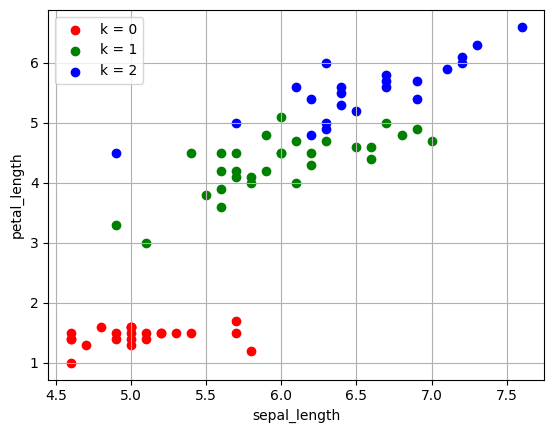

In [130]:
for k, color in enumerate(['r', 'g', 'b']):
    plt.scatter(x_train[y_train == k, 0], x_train[y_train == k, 1], c=color, label=f'k = {k}')
plt.xlabel('sepal_length')
plt.ylabel('petal_length')
plt.legend()
plt.grid()
plt.show()


## モデル定義

In [131]:
n_input = x_train.shape[1] # 入力次元
n_output = len(np.unique(y_train)) # 出力次元

print(n_input, n_output)


2 3


In [132]:
class Net(nn.Module):
    def __init__(self, n_input, n_output):
        super().__init__()

        self.l1 = nn.Linear(n_input, n_output)
    
    def forward(self, x):
        x1 = self.l1(x)
        return x1

net = Net(n_input=n_input, n_output=n_output)


## モデル内のパラメータ確認

In [133]:
for parameter in net.named_parameters():
    print(parameter)


('l1.weight', Parameter containing:
tensor([[-0.0065, -0.2568],
        [-0.2538,  0.5339],
        [-0.2777,  0.4669]], requires_grad=True))
('l1.bias', Parameter containing:
tensor([-0.1063,  0.1897, -0.1726], requires_grad=True))


## データのテンソル化

In [134]:
inputs_train = torch.tensor(x_train, dtype=torch.float32) # shape: [batch_size, feature_dim]
labels_train = torch.tensor(y_train, dtype=torch.long) # shape: [batch_size]

inputs_valid = torch.tensor(x_valid, dtype=torch.float32) # shape: [batch_size, feature_dim]
labels_valid = torch.tensor(y_valid, dtype=torch.long) # shape: [batch_size]

print(inputs_train.shape, labels_train.shape)
print(inputs_valid.shape, labels_valid.shape)


torch.Size([75, 2]) torch.Size([75])
torch.Size([75, 2]) torch.Size([75])


## 学習ループ

In [135]:
epochs = 10000

criterion = nn.CrossEntropyLoss() # 損失関数

lr = 0.01 # 学習率
optimizer = optim.SGD(net.parameters(), lr=lr) # 最適化関数

history = np.zeros((0, 5))


In [136]:
for epoch in range(epochs):
    # 訓練
    optimizer.zero_grad() # 勾配の初期化
    outputs = net(inputs_train) # 予測
    loss = criterion(outputs, labels_train) # 損失
    loss.backward() # 勾配計算
    optimizer.step() # パラメータ更新

    # 訓練の記録
    loss_train = loss # 損失
    values, indices = torch.max(outputs, dim=1) # 最大値・クラス番号
    acc_train = (indices == labels_train).float().mean() # 正解率

    with torch.no_grad():
        # 検証
        outputs = net(inputs_valid) # 予測
        loss = criterion(outputs, labels_valid) # 損失

        # 検証の記録
        loss_valid = loss # 損失
        values, indices = torch.max(outputs, dim=1) # 最大値・クラス番号
        acc_valid = (indices == labels_valid).float().mean() # 正解率
    
    # 学習履歴の記録
    if (epoch % 10) == 0:
        item = np.array([epoch, loss_train.item(), acc_train.item(), loss_valid.item(), acc_valid.item()])
        history = np.vstack((history, item))
        print(f"epoch: {epoch}, loss_train: {loss_train}, acc_train: {acc_train}, loss_valid: {loss_valid}, acc_valid: {acc_valid}")


epoch: 0, loss_train: 0.8770591020584106, acc_train: 0.4266666769981384, loss_valid: 0.943754255771637, acc_valid: 0.3199999928474426
epoch: 10, loss_train: 0.7792620062828064, acc_train: 0.7066666483879089, loss_valid: 0.7981035113334656, acc_valid: 0.6266666650772095
epoch: 20, loss_train: 0.7592262029647827, acc_train: 0.7066666483879089, loss_valid: 0.7680583596229553, acc_valid: 0.6266666650772095
epoch: 30, loss_train: 0.7464202642440796, acc_train: 0.7066666483879089, loss_valid: 0.7518686056137085, acc_valid: 0.6266666650772095
epoch: 40, loss_train: 0.7351562976837158, acc_train: 0.7066666483879089, loss_valid: 0.7387994527816772, acc_valid: 0.6266666650772095
epoch: 50, loss_train: 0.7246301174163818, acc_train: 0.7066666483879089, loss_valid: 0.7270010709762573, acc_valid: 0.6266666650772095
epoch: 60, loss_train: 0.7146971821784973, acc_train: 0.7066666483879089, loss_valid: 0.7160236835479736, acc_valid: 0.6266666650772095
epoch: 70, loss_train: 0.7052996158599854, acc_tra

## `outputs`のカタチ

In [137]:
with torch.no_grad():
    # 検証
    outputs = net(inputs_valid) # 予測
    print(outputs.shape)
    print(outputs[:5, :])
    loss = criterion(outputs, labels_valid) # 損失

    # 検証の記録
    loss_valid = loss # 損失
    values, indices = torch.max(outputs, dim=1) # 最大値・クラス番号
    acc_valid = (indices == labels_valid).float().mean() # 正解率


torch.Size([75, 3])
tensor([[-3.8541,  2.2202,  1.8007],
        [-4.9111,  2.3526,  2.9027],
        [-6.0087,  2.3094,  4.3331],
        [-2.5082,  2.0390,  0.4175],
        [ 5.2032,  1.6524, -8.5394]])


## 学習曲線

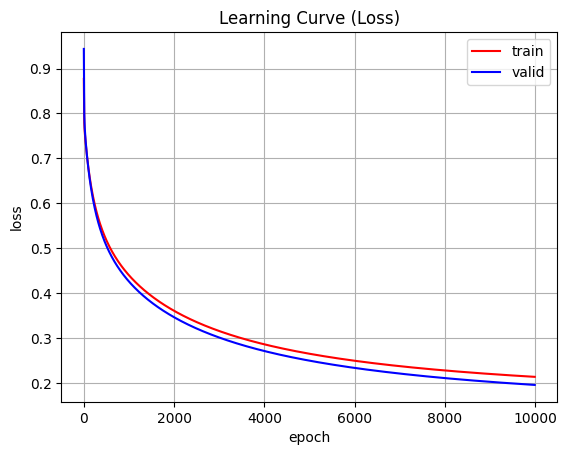

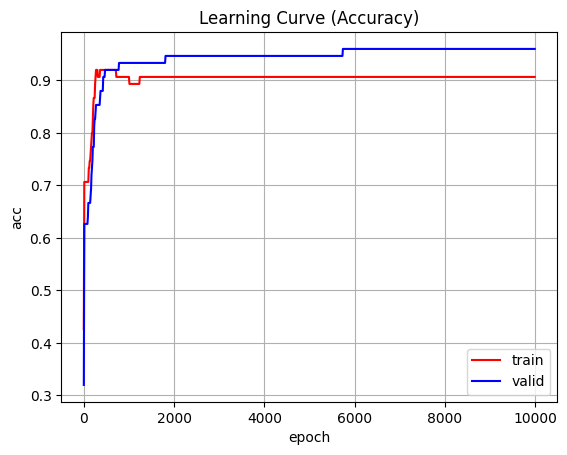

In [138]:
plt.plot(history[:, 0], history[:, 1], c='r', label='train')
plt.plot(history[:, 0], history[:, 3], c='b', label='valid')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title("Learning Curve (Loss)")
plt.legend()
plt.grid()
plt.show()

plt.plot(history[:, 0], history[:, 2], c='r', label='train')
plt.plot(history[:, 0], history[:, 4], c='b', label='valid')
plt.xlabel('epoch')
plt.ylabel('acc')
plt.title("Learning Curve (Accuracy)")
plt.legend()
plt.grid()
plt.show()


## モデル出力の確認

In [139]:
# 正解ラベルが0, 1, 2のサンプルを適当に抽出
print(labels_train[[0, 2, 3]])


tensor([1, 0, 2])


In [140]:
inputs_3samples = inputs_train[[0, 2, 3], :]
print(inputs_3samples.detach().numpy()) # 計算グラフから切り離した後に変換


[[6.3 4.7]
 [5.  1.6]
 [6.4 5.6]]


In [141]:
softmax = nn.Softmax(dim=1)

outputs_3samples = net(inputs_3samples)
probs_3samples = softmax(outputs_3samples)

np.set_printoptions(suppress=True) # 指数表示をヤメロ
print(outputs_3samples.detach().numpy())
print(probs_3samples.detach().numpy())


[[-3.1840038  2.1985297  1.0035249]
 [ 4.7237644  1.6875033 -8.00009  ]
 [-6.008666   2.3094032  4.3330765]]
[[0.00351577 0.76493615 0.23154807]
 [0.954183   0.04581421 0.00000284]
 [0.00002849 0.11673638 0.88323516]]


## 重み行列とバイアス

In [142]:
print(net.l1.weight.data)
print(net.l1.weight.shape)
print()

print(net.l1.bias.data)
print(net.l1.bias.shape)


tensor([[ 1.9063, -3.3503],
        [ 0.1351,  0.1082],
        [-2.5795,  3.9861]])
torch.Size([3, 2])

tensor([ 0.5526,  0.8387, -1.4805])
torch.Size([3])


## おまけ：入力変数の4次元化

In [143]:
x_train, x_valid, y_train, y_valid = train_test_split(x_org, y_org, train_size=0.5, test_size=0.5, random_state=123)
print(x_train.shape, x_valid.shape, y_train.shape, y_valid.shape)


(75, 4) (75, 4) (75,) (75,)


In [144]:
n_input = x_train.shape[1] # 入力次元
n_output = len(np.unique(y_train)) # 出力次元

print(n_input, n_output)


4 3


In [145]:
class Net(nn.Module):
    def __init__(self, n_input, n_output):
        super().__init__()

        self.l1 = nn.Linear(n_input, n_output)
    
    def forward(self, x):
        x1 = self.l1(x)
        return x1

net = Net(n_input=n_input, n_output=n_output)


In [146]:
inputs_train = torch.tensor(x_train, dtype=torch.float32) # shape: [batch_size, feature_dim]
labels_train = torch.tensor(y_train, dtype=torch.long) # shape: [batch_size]

inputs_valid = torch.tensor(x_valid, dtype=torch.float32) # shape: [batch_size, feature_dim]
labels_valid = torch.tensor(y_valid, dtype=torch.long) # shape: [batch_size]

print(inputs_train.shape, labels_train.shape)
print(inputs_valid.shape, labels_valid.shape)


torch.Size([75, 4]) torch.Size([75])
torch.Size([75, 4]) torch.Size([75])


In [147]:
epochs = 10000

criterion = nn.CrossEntropyLoss() # 損失関数

lr = 0.01 # 学習率
optimizer = optim.SGD(net.parameters(), lr=lr) # 最適化関数

history = np.zeros((0, 5))


In [148]:
for epoch in range(epochs):
    # 訓練
    optimizer.zero_grad() # 勾配の初期化
    outputs = net(inputs_train) # 予測
    loss = criterion(outputs, labels_train) # 損失
    loss.backward() # 勾配計算
    optimizer.step() # パラメータ更新

    # 訓練の記録
    loss_train = loss # 損失
    values, indices = torch.max(outputs, dim=1) # 最大値・クラス番号
    acc_train = (indices == labels_train).float().mean() # 正解率

    with torch.no_grad():
        # 検証
        outputs = net(inputs_valid) # 予測
        loss = criterion(outputs, labels_valid) # 損失

        # 検証の記録
        loss_valid = loss # 損失
        values, indices = torch.max(outputs, dim=1) # 最大値・クラス番号
        acc_valid = (indices == labels_valid).float().mean() # 正解率
    
    # 学習履歴の記録
    if (epoch % 10) == 0:
        item = np.array([epoch, loss_train.item(), acc_train.item(), loss_valid.item(), acc_valid.item()])
        history = np.vstack((history, item))
        print(f"epoch: {epoch}, loss_train: {loss_train}, acc_train: {acc_train}, loss_valid: {loss_valid}, acc_valid: {acc_valid}")


epoch: 0, loss_train: 2.4401729106903076, acc_train: 0.4000000059604645, loss_valid: 2.6144750118255615, acc_valid: 0.2666666805744171
epoch: 10, loss_train: 1.6493194103240967, acc_train: 0.5866666436195374, loss_valid: 1.7476435899734497, acc_valid: 0.47999998927116394
epoch: 20, loss_train: 1.53745436668396, acc_train: 0.4000000059604645, loss_valid: 1.600732684135437, acc_valid: 0.4399999976158142
epoch: 30, loss_train: 1.4431017637252808, acc_train: 0.41333332657814026, loss_valid: 1.4922765493392944, acc_valid: 0.4399999976158142
epoch: 40, loss_train: 1.354435682296753, acc_train: 0.4266666769981384, loss_valid: 1.3937371969223022, acc_valid: 0.4533333480358124
epoch: 50, loss_train: 1.271704912185669, acc_train: 0.4266666769981384, loss_valid: 1.3028391599655151, acc_valid: 0.4533333480358124
epoch: 60, loss_train: 1.1954134702682495, acc_train: 0.4533333480358124, loss_valid: 1.2196978330612183, acc_valid: 0.46666666865348816
epoch: 70, loss_train: 1.1258748769760132, acc_trai

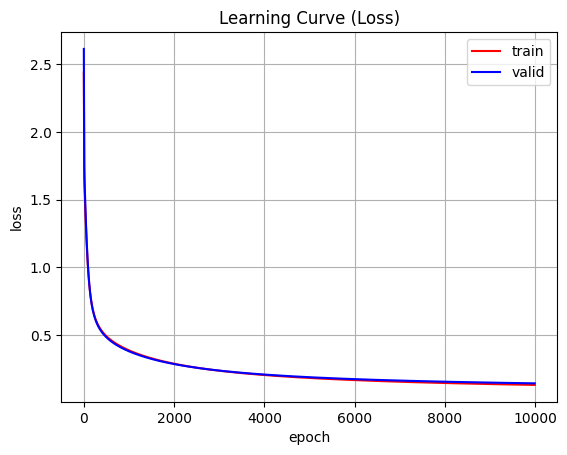

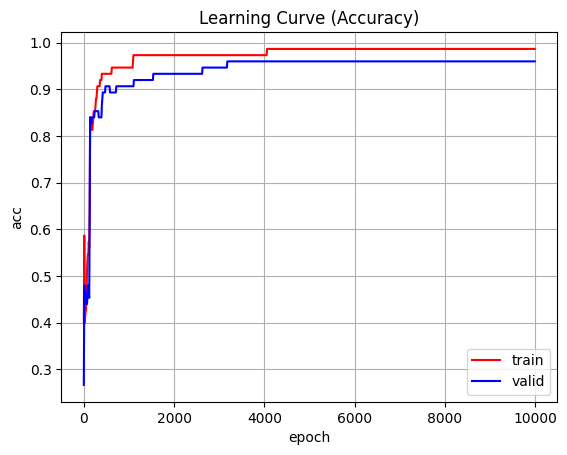

In [149]:
plt.plot(history[:, 0], history[:, 1], c='r', label='train')
plt.plot(history[:, 0], history[:, 3], c='b', label='valid')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title("Learning Curve (Loss)")
plt.legend()
plt.grid()
plt.show()

plt.plot(history[:, 0], history[:, 2], c='r', label='train')
plt.plot(history[:, 0], history[:, 4], c='b', label='valid')
plt.xlabel('epoch')
plt.ylabel('acc')
plt.title("Learning Curve (Accuracy)")
plt.legend()
plt.grid()
plt.show()
